---

## Optimized simulation functions

The original policies recompute means by looping through all past observations at every round, making them $O(t)$ per call and $O(n^2)$ overall. Below we define **optimized versions** that maintain running counts and sums, reducing each policy call to $O(1)$.

To speed up the simulations, the evaluation policy was optimized by replacing the full history of actions and rewards with a smaller set of sufficient statistics, namely the number of pulls of each arm (`counts`), the cumulative rewards of each arm (`sums`), and the current round `t`. In the original implementation, the policy received the full vectors of past rewards and actions and recomputed empirical means and counts at every step. This is simple and transparent, but it becomes computationally expensive because the same information is processed repeatedly. In the optimized version, the relevant statistics are updated incrementally after each round, so the policy can make its decision directly from the current state without reconstructing the entire history.

The main advantage of this approach is computational efficiency. Since the algorithm no longer loops over all past observations at every round, simulations become much faster and can be run for larger horizons or for more repetitions. This is particularly useful when comparing several policies or when plotting average regret over many runs. A second advantage is that the optimized version is more memory-efficient, because it does not need to store the full reward and action history. More generally, this approach is appropriate whenever the policy depends only on empirical counts and averages, as is the case for uniform allocation, epsilon-greedy, UCB, MOSS, and Thompson Sampling in the Bernoulli setting.

However, this optimization also has some disadvantages. First, it makes the code less intuitive, because the policy no longer works directly with the observed data but only with summary statistics. As a result, the implementation can be harder to interpret and debug. Second, the optimized approach is less flexible: it works only for algorithms whose decisions depend entirely on these sufficient statistics. If a policy required more detailed information about the order of past rewards or actions, then this compressed representation would no longer be enough. Therefore, while the optimized implementation is very useful for simulation speed, it must be checked carefully to ensure that it remains equivalent to the original policy.

In [12]:
# ── Optimized eval functions ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np


def eval_pol_fast(pol, n, delta, n_rep, normal=True):
    """Fast version of eval_pol: passes (counts, sums, t) to the policy."""
    np.random.seed(1)
    regret_matrix = np.full((n_rep, n), np.nan)

    for i in range(n_rep):
        counts = np.zeros(2)
        sums = np.zeros(2)

        for j in range(n):
            if normal:
                Y_t = np.random.normal(loc=[1/2, delta], scale=1, size=2)
            else:
                Y_t = np.array([np.random.uniform(0, 1/2), np.random.uniform(0, delta)])

            t = j + 1
            as_t = pol(counts, sums, t)
            regret_matrix[i, j] = Y_t[0] - Y_t[as_t]

            counts[as_t] += 1
            sums[as_t] += Y_t[as_t]

        regret_matrix[i, :] = np.cumsum(regret_matrix[i, :])

    return regret_matrix


def eval_pol_bernoulli_fast(pol, n, K, mus, n_rep):
    """Fast version of eval_pol_bernoulli: passes (counts, sums, t) to the policy."""
    np.random.seed(1)
    mu_star = max(mus)
    regret_matrix = np.full((n_rep, n), np.nan)

    for i in range(n_rep):
        counts = np.zeros(K)
        sums = np.zeros(K)

        for j in range(n):
            Y_t = np.array([np.random.binomial(1, mu) for mu in mus])

            t = j + 1
            as_t = pol(counts, sums, t)
            regret_matrix[i, j] = mu_star - mus[as_t]

            counts[as_t] += 1
            sums[as_t] += Y_t[as_t]

        regret_matrix[i, :] = np.cumsum(regret_matrix[i, :])

    return regret_matrix


# ── Optimized policies ───────────────────────────────────────────────────────

def unif_alloc_fast(counts, sums, t):
    return (t - 1) % 2

def eps_greedy_fast(counts, sums, t, eps=0.1):
    K = len(counts)
    if t <= K:
        return t - 1
    randv = np.random.binomial(1, 1 - eps)
    means = sums / np.where(counts > 0, counts, 1)
    h = np.argsort(means)[::-1]
    return h[0] if randv == 1 else h[1]

def ucb_fast(counts, sums, t):
    K = len(counts)
    if t <= K:
        return t - 1
    means = sums / np.where(counts > 0, counts, 1)
    bonuses = np.sqrt(2 * np.log(1 + t * np.log(t)**2) / np.where(counts > 0, counts, 1))
    return np.argmax(means + bonuses)

def moss_fast(counts, sums, t):
    K = len(counts)
    if t <= K:
        return t - 1
    means = sums / np.where(counts > 0, counts, 1)
    bonuses = np.sqrt(np.maximum(0, np.log(t / (K * np.where(counts > 0, counts, 1)))) / np.where(counts > 0, counts, 1))
    return np.argmax(means + bonuses)

def thompson_sampling_fast(counts, sums, t, K=2):
    if t <= K:
        return t - 1
    alpha = 1 + sums[:K]
    beta_param = 1 + counts[:K] - sums[:K]
    samples = np.random.beta(alpha, beta_param)
    return np.argmax(samples)

def eps_greedy_decreasing_fast(counts, sums, t, c=1.0):
    K = len(counts)
    if t <= K:
        return t - 1
    eps_t = min(1.0, c / t)
    randv = np.random.binomial(1, 1 - eps_t)
    means = sums / np.where(counts > 0, counts, 1)
    h = np.argsort(means)[::-1]
    return h[0] if randv == 1 else h[1]

print("Optimized functions loaded.")

Optimized functions loaded.


# Task 1: Difficulty of the bandit problem

We run simulations for $\delta \in \{0.40, 0.25, 0.10, 0.02\}$ using $n = 10\,000$ rounds and $n_{\mathrm{rep}} = 50$ repetitions. For each $\delta$ we plot the average cumulative regret of all four policies (Uniform Allocation, $\epsilon$-greedy, UCB, MOSS) side by side for both the normal and uniform reward distributions.

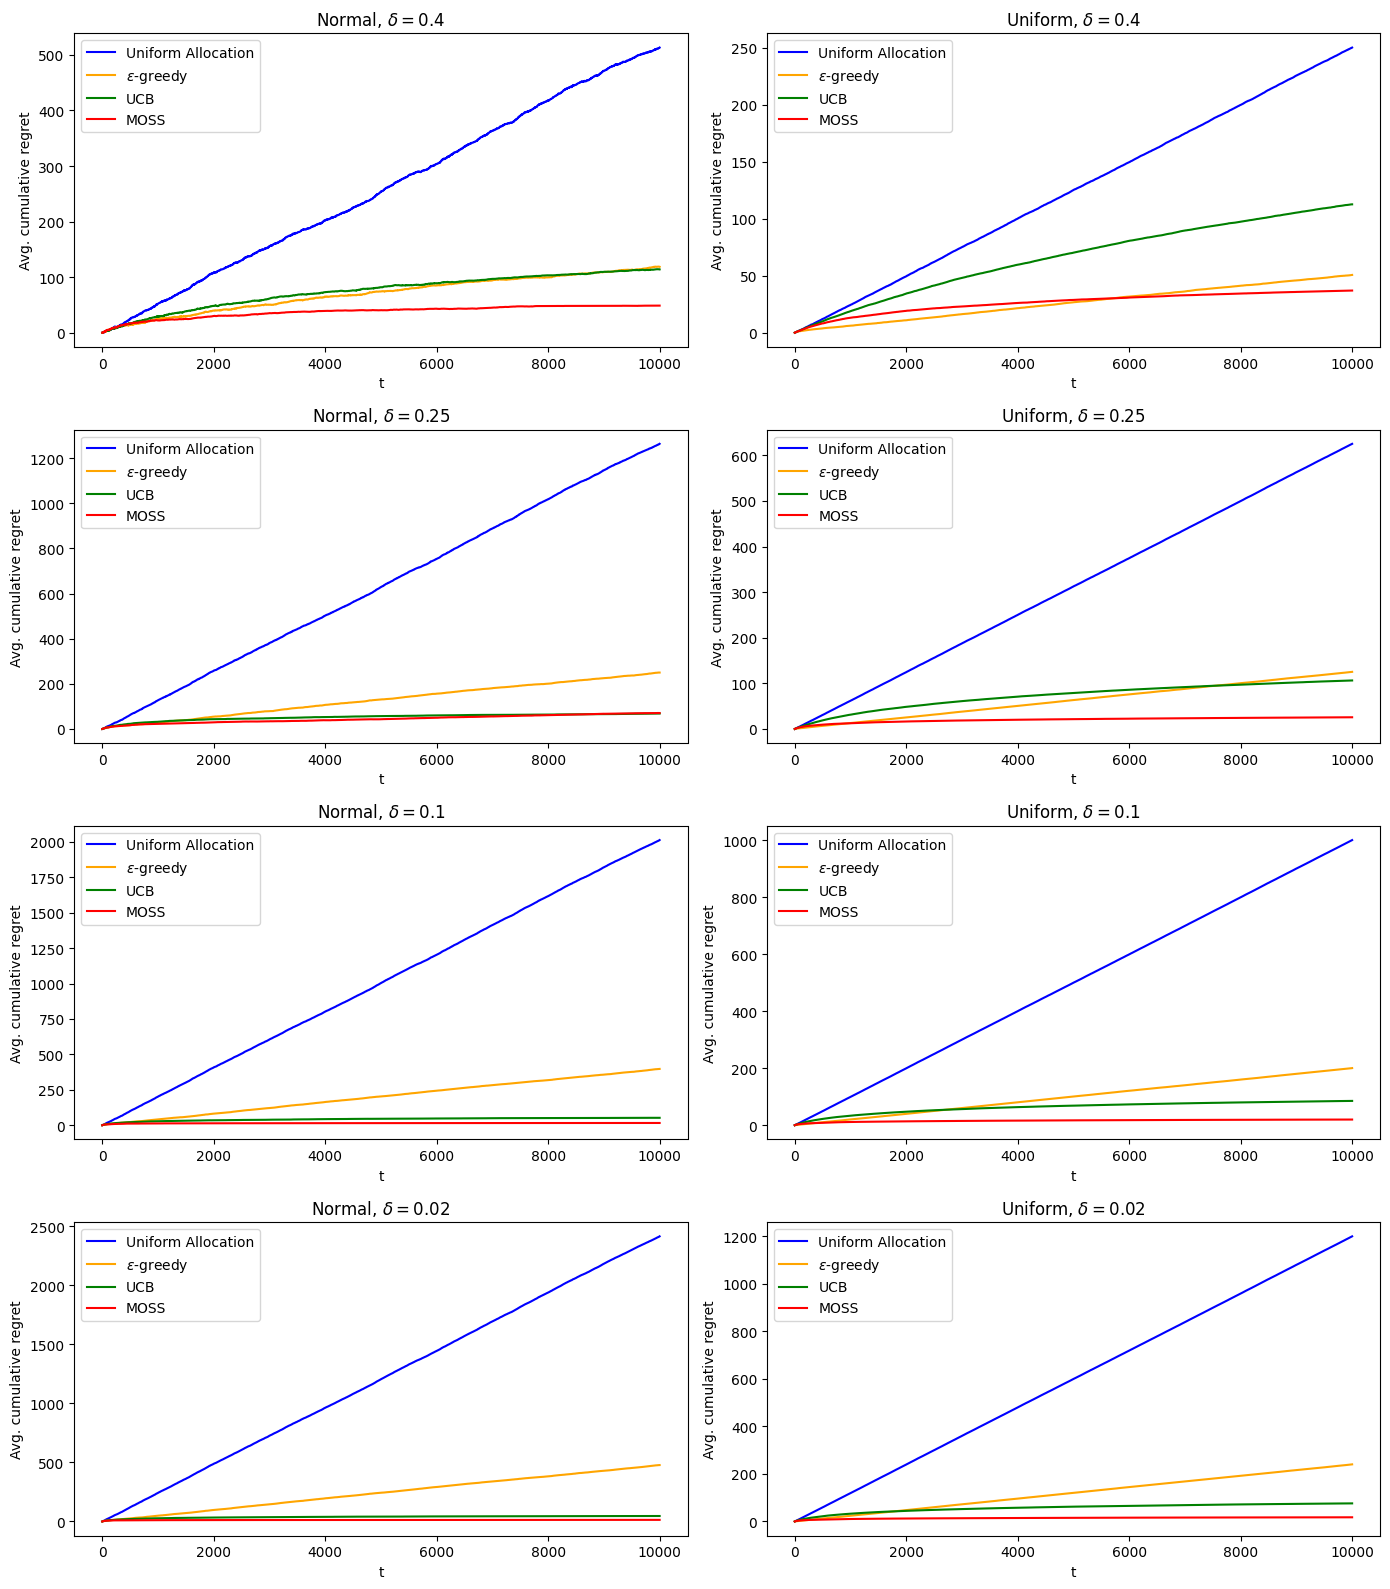

In [14]:
n = 10000
n_rep = 50
deltas = [0.40, 0.25, 0.10, 0.02]
policies = {
    "Uniform Allocation": unif_alloc_fast,
    r"$\epsilon$-greedy": eps_greedy_fast,
    "UCB": ucb_fast,
    "MOSS": moss_fast,
}
colors = {"Uniform Allocation": "blue", r"$\epsilon$-greedy": "orange", "UCB": "green", "MOSS": "red"}

fig, axes = plt.subplots(len(deltas), 2, figsize=(14, 4 * len(deltas)))

for row, delta in enumerate(deltas):
    for name, pol in policies.items():
        # Normal distribution
        R_normal = eval_pol_fast(pol, n, delta, n_rep, normal=True)
        axes[row, 0].plot(np.mean(R_normal, axis=0), label=name, color=colors[name])
        # Uniform distribution
        R_uniform = eval_pol_fast(pol, n, delta, n_rep, normal=False)
        axes[row, 1].plot(np.mean(R_uniform, axis=0), label=name, color=colors[name])

    axes[row, 0].set_title(f"Normal, $\\delta = {delta}$")
    axes[row, 0].set_xlabel("t")
    axes[row, 0].set_ylabel("Avg. cumulative regret")
    axes[row, 0].legend()

    axes[row, 1].set_title(f"Uniform, $\\delta = {delta}$")
    axes[row, 1].set_xlabel("t")
    axes[row, 1].set_ylabel("Avg. cumulative regret")
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

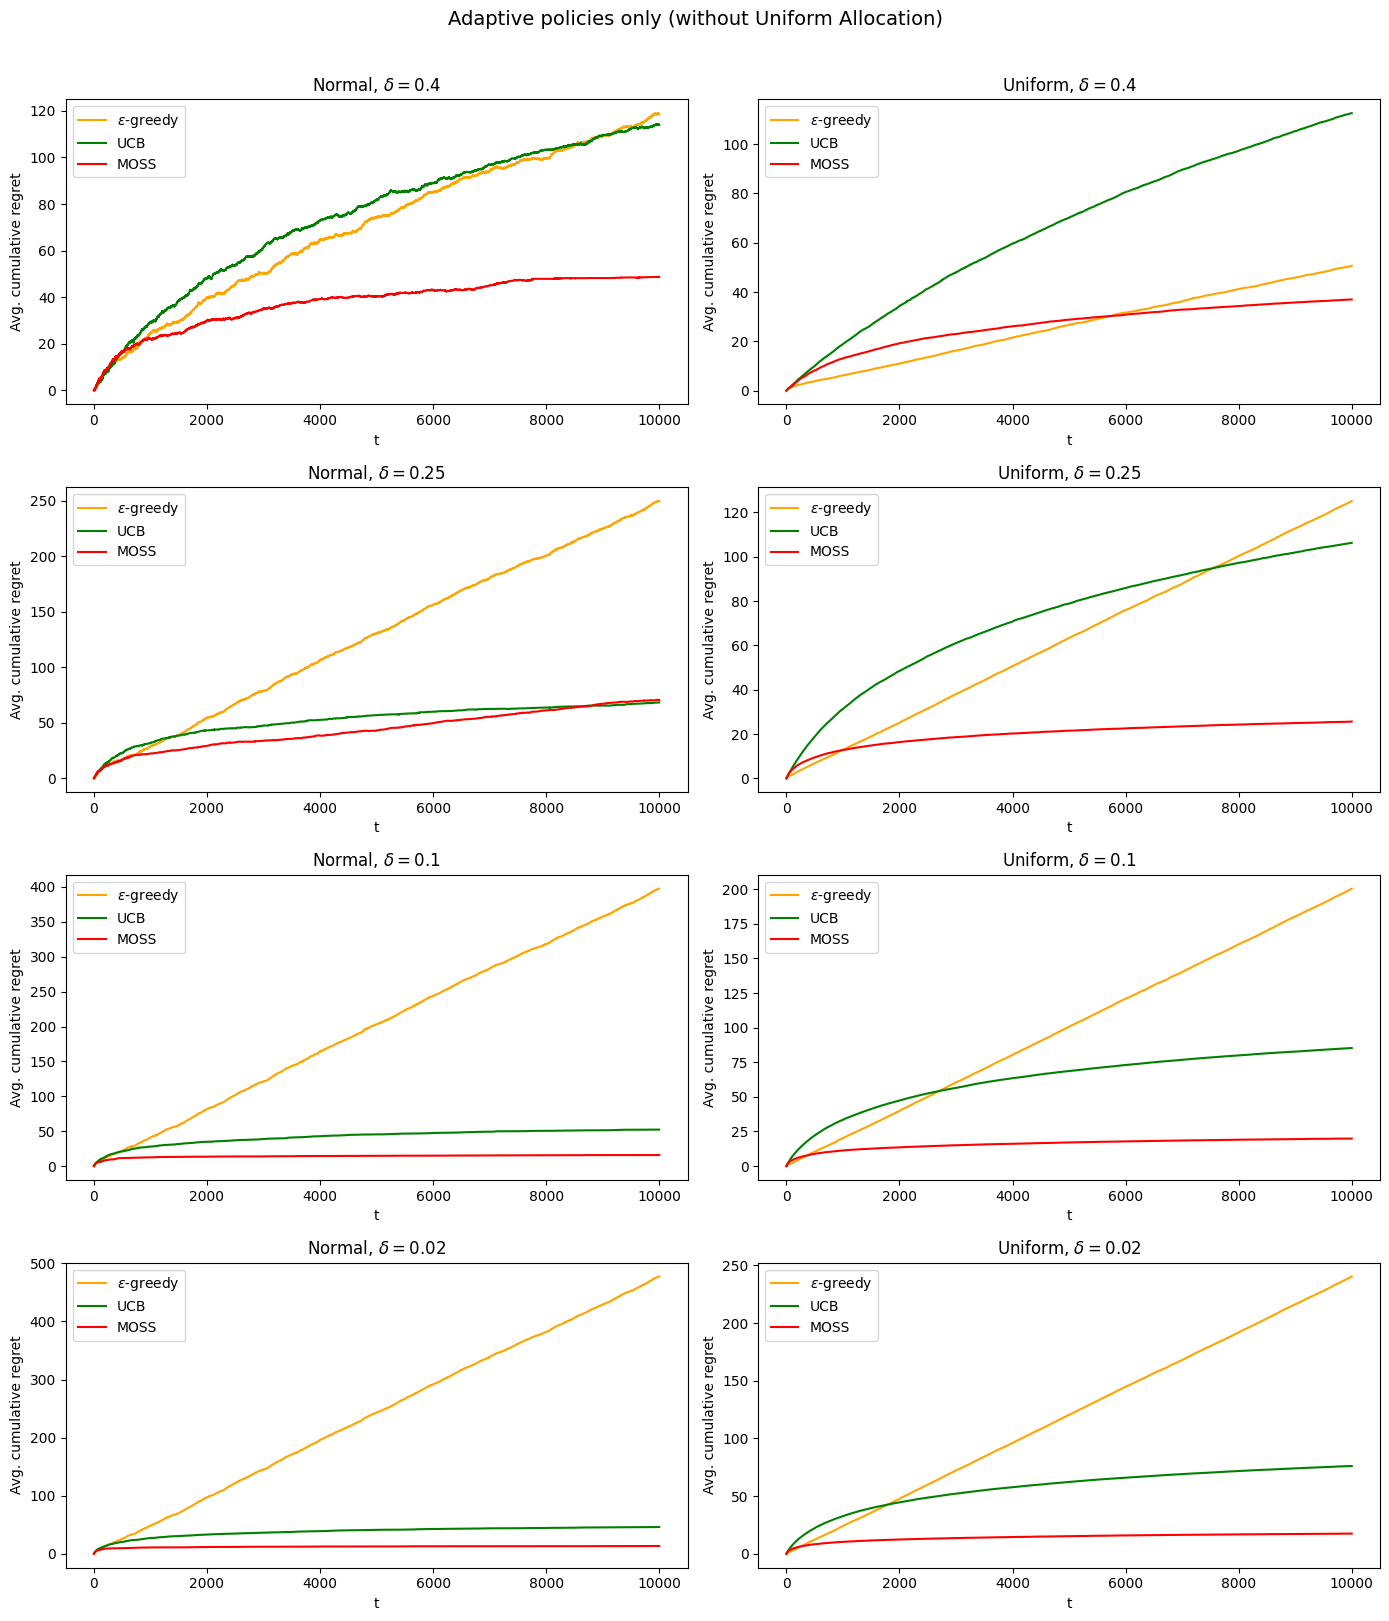

In [13]:
# Same plot without Uniform Allocation (to better compare the adaptive policies)
policies_no_unif = {
    r"$\epsilon$-greedy": eps_greedy_fast,
    "UCB": ucb_fast,
    "MOSS": moss_fast,
}
colors_no_unif = {r"$\epsilon$-greedy": "orange", "UCB": "green", "MOSS": "red"}

fig, axes = plt.subplots(len(deltas), 2, figsize=(14, 4 * len(deltas)))

for row, delta in enumerate(deltas):
    for name, pol in policies_no_unif.items():
        R_normal = eval_pol_fast(pol, n, delta, n_rep, normal=True)
        axes[row, 0].plot(np.mean(R_normal, axis=0), label=name, color=colors_no_unif[name])
        R_uniform = eval_pol_fast(pol, n, delta, n_rep, normal=False)
        axes[row, 1].plot(np.mean(R_uniform, axis=0), label=name, color=colors_no_unif[name])

    axes[row, 0].set_title(f"Normal, $\\delta = {delta}$")
    axes[row, 0].set_xlabel("t")
    axes[row, 0].set_ylabel("Avg. cumulative regret")
    axes[row, 0].legend()

    axes[row, 1].set_title(f"Uniform, $\\delta = {delta}$")
    axes[row, 1].set_xlabel("t")
    axes[row, 1].set_ylabel("Avg. cumulative regret")
    axes[row, 1].legend()

plt.suptitle("Adaptive policies only (without Uniform Allocation)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Discussion

**How difficulty changes with $\delta$:**

The parameter $\delta$ controls the mean of the inferior arm. The reward gap is $\Delta = \mu_1 - \mu_2 = 1/2 - \delta$. As $\delta$ increases toward $1/2$, $\Delta$ shrinks and the problem becomes *harder* — it takes more samples to distinguish which arm is better.

- **$\delta = 0.02$ (large gap $\Delta = 0.48$):** The gap is easy to detect. Policies like UCB and MOSS quickly identify the optimal arm and accumulate little regret. However, a pull of the suboptimal arm then causes a larger regret, since each mistake costs exactly $0.5-\delta$. For this reason, cumulative regret can be higher when $\delta$ is smaller, even though the learning problem is easier. This effect is especially clear for policies such as uniform allocation and fixed-$\epsilon$ greedy, which continue to pull the inferior arm many times. Therefore, the figures do not contradict the theory: smaller $\delta$ makes the arms easier to distinguish, but it also makes each wrong decision more expensive.
- **$\delta = 0.40$ (small gap $\Delta = 0.10$):** The reward distributions overlap significantly, requiring more exploration before the best arm can be identified.

**Algorithm comparison:**

1. **Uniform Allocation** always has linear regret — it pulls the suboptimal arm 50% of the time regardless of observations ($O(\sqrt{Kn})$)
2. **$\epsilon$-greedy** also has linear regret (slope $\approx \epsilon \cdot \Delta / 2$) because it keeps exploring at a fixed rate forever, but the slope is much smaller than uniform allocation (O(n)).
3. **UCB** achieves sublinear (logarithmic) regret by systematically reducing exploration of the inferior arm as confidence grows ($O(\sqrt{Kn\log K})$)
4. **MOSS** also achieves sublinear regret and is designed to be minimax optimal with regret growing as $O(\sqrt{Kn})$ in the worst case.


# Task 2: Sensitivity of $\epsilon$-greedy

We run simulations for $\epsilon \in \{0.01, 0.05, 0.10, 0.20\}$ with $n = 10\,000$, $\delta = 0.25$, and $n_{\mathrm{rep}} = 50$ to study how the exploration parameter affects performance. We then propose a time-dependent $\epsilon(t)$ schedule and compare it to the fixed-$\epsilon$ variants.

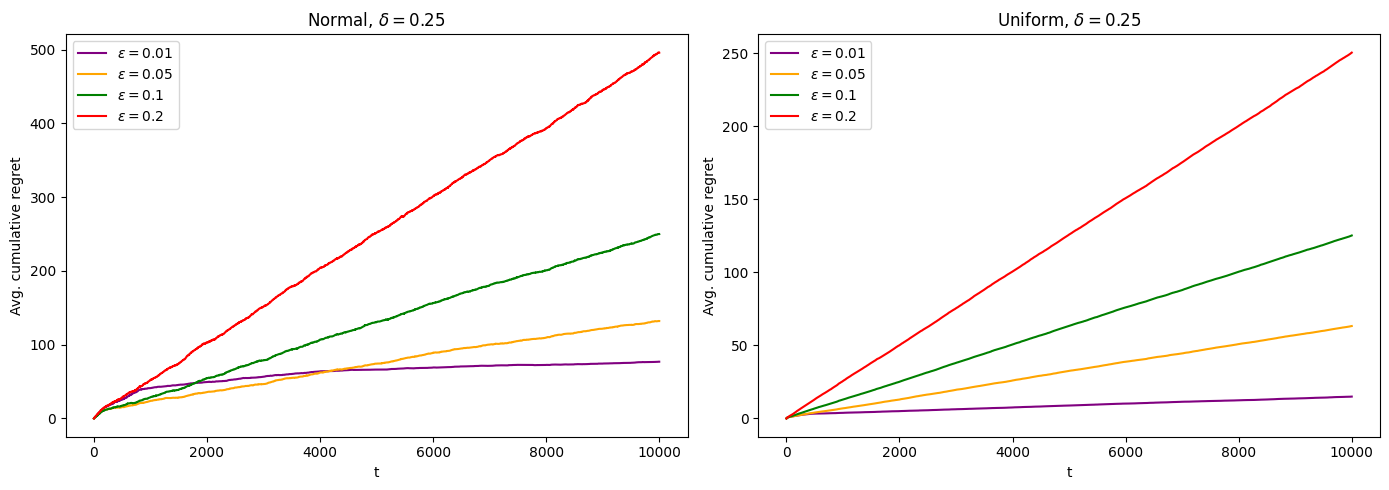

In [4]:
# --- Part 1: Compare fixed epsilon values ---
n = 10000
n_rep = 50
delta = 0.25
epsilons = [0.01, 0.05, 0.10, 0.20]
colors_eps = ["purple", "orange", "green", "red"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for eps_val, col in zip(epsilons, colors_eps):
    pol = lambda counts, sums, t, e=eps_val: eps_greedy_fast(counts, sums, t, eps=e)
    R_normal = eval_pol_fast(pol, n, delta, n_rep, normal=True)
    R_uniform = eval_pol_fast(pol, n, delta, n_rep, normal=False)
    axes[0].plot(np.mean(R_normal, axis=0), label=f"$\\epsilon = {eps_val}$", color=col)
    axes[1].plot(np.mean(R_uniform, axis=0), label=f"$\\epsilon = {eps_val}$", color=col)

axes[0].set_title(f"Normal, $\\delta = {delta}$")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Avg. cumulative regret")
axes[0].legend()

axes[1].set_title(f"Uniform, $\\delta = {delta}$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Avg. cumulative regret")
axes[1].legend()

plt.tight_layout()
plt.show()

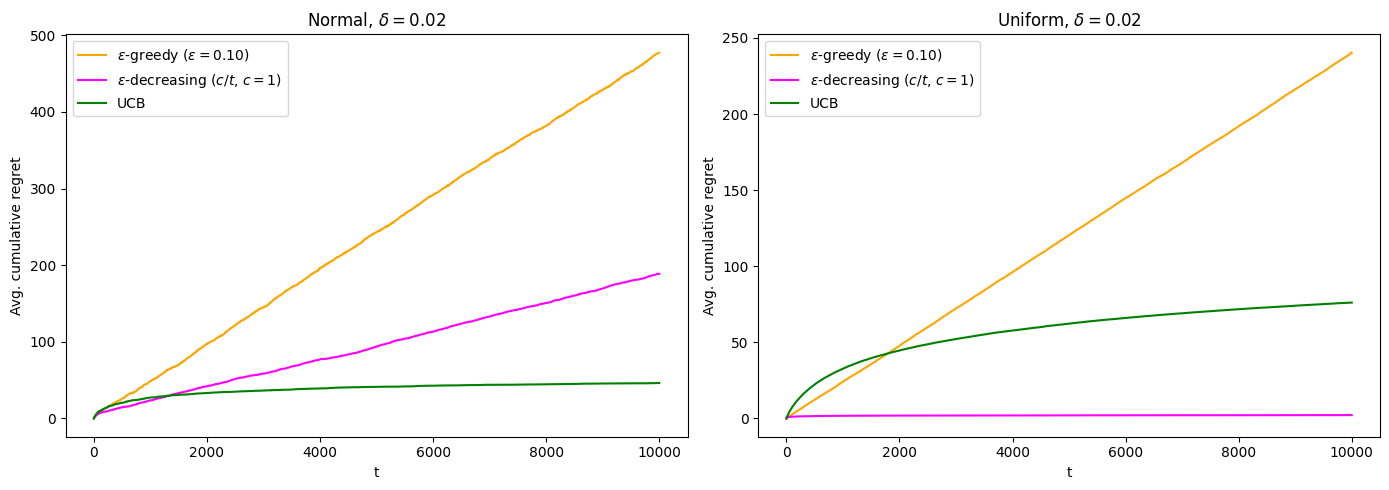

In [19]:
# --- Part 2: Time-dependent epsilon-greedy ---
# Compare fixed eps=0.10 vs decreasing eps vs UCB
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pol_fixed = lambda counts, sums, t: eps_greedy_fast(counts, sums, t, eps=0.10)
pol_dec = lambda counts, sums, t: eps_greedy_decreasing_fast(counts, sums, t, c=1.0)

for pol, name, col in [
    (pol_fixed, r"$\epsilon$-greedy ($\epsilon=0.10$)", "orange"),
    (pol_dec, r"$\epsilon$-decreasing ($c/t$, $c=1$)", "magenta"),
    (ucb_fast, "UCB", "green"),
]:
    R_normal = eval_pol_fast(pol, n, delta, n_rep, normal=True)
    R_uniform = eval_pol_fast(pol, n, delta, n_rep, normal=False)
    axes[0].plot(np.mean(R_normal, axis=0), label=name, color=col)
    axes[1].plot(np.mean(R_uniform, axis=0), label=name, color=col)

axes[0].set_title(f"Normal, $\\delta = {delta}$")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Avg. cumulative regret")
axes[0].legend()

axes[1].set_title(f"Uniform, $\\delta = {delta}$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Avg. cumulative regret")
axes[1].legend()

plt.tight_layout()
plt.show()

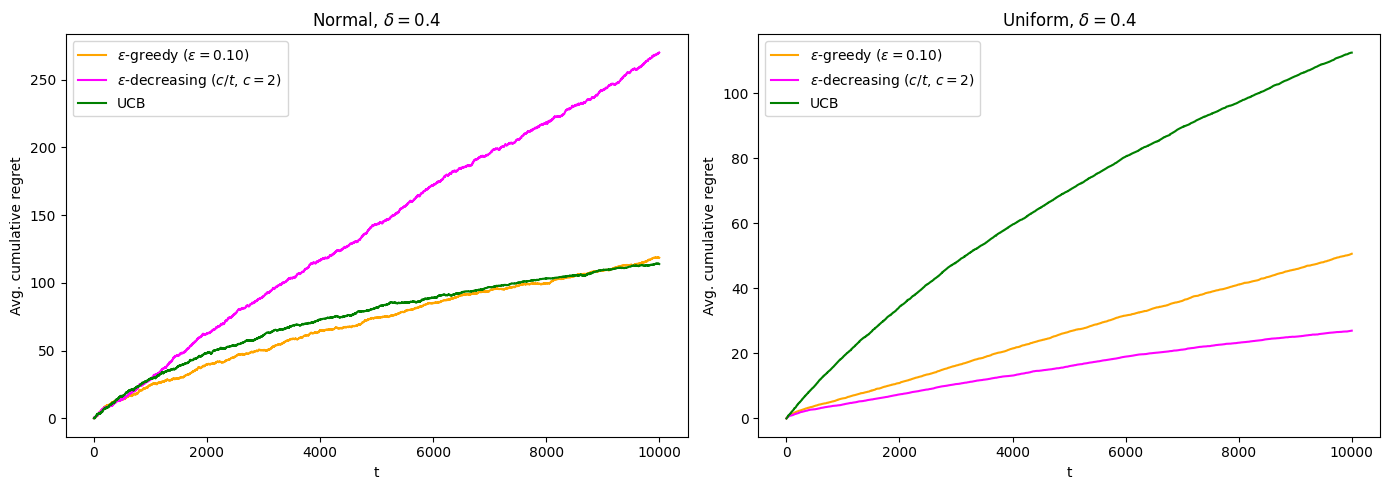

In [23]:
# --- Part 2: Time-dependent epsilon-greedy ---
# Compare fixed eps=0.10 vs decreasing eps vs UCB
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pol_fixed = lambda counts, sums, t: eps_greedy_fast(counts, sums, t, eps=0.10)
pol_dec = lambda counts, sums, t: eps_greedy_decreasing_fast(counts, sums, t, c=2.0)

for pol, name, col in [
    (pol_fixed, r"$\epsilon$-greedy ($\epsilon=0.10$)", "orange"),
    (pol_dec, r"$\epsilon$-decreasing ($c/t$, $c=2$)", "magenta"),
    (ucb_fast, "UCB", "green"),
]:
    R_normal = eval_pol_fast(pol, n, delta, n_rep, normal=True)
    R_uniform = eval_pol_fast(pol, n, delta, n_rep, normal=False)
    axes[0].plot(np.mean(R_normal, axis=0), label=name, color=col)
    axes[1].plot(np.mean(R_uniform, axis=0), label=name, color=col)

axes[0].set_title(f"Normal, $\\delta = {delta}$")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Avg. cumulative regret")
axes[0].legend()

axes[1].set_title(f"Uniform, $\\delta = {delta}$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Avg. cumulative regret")
axes[1].legend()

plt.tight_layout()
plt.show()

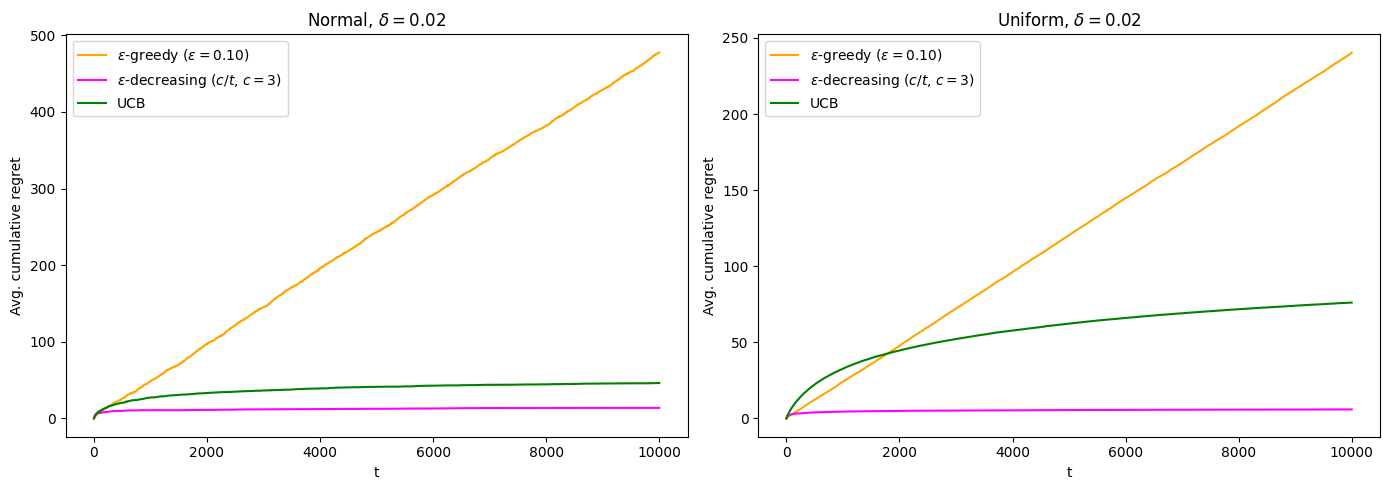

In [17]:
# --- Part 2: Time-dependent epsilon-greedy ---
# Compare fixed eps=0.10 vs decreasing eps vs UCB
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pol_fixed = lambda counts, sums, t: eps_greedy_fast(counts, sums, t, eps=0.10)
pol_dec = lambda counts, sums, t: eps_greedy_decreasing_fast(counts, sums, t, c=3.0)

for pol, name, col in [
    (pol_fixed, r"$\epsilon$-greedy ($\epsilon=0.10$)", "orange"),
    (pol_dec, r"$\epsilon$-decreasing ($c/t$, $c=3$)", "magenta"),
    (ucb_fast, "UCB", "green"),
]:
    R_normal = eval_pol_fast(pol, n, delta, n_rep, normal=True)
    R_uniform = eval_pol_fast(pol, n, delta, n_rep, normal=False)
    axes[0].plot(np.mean(R_normal, axis=0), label=name, color=col)
    axes[1].plot(np.mean(R_uniform, axis=0), label=name, color=col)

axes[0].set_title(f"Normal, $\\delta = {delta}$")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Avg. cumulative regret")
axes[0].legend()

axes[1].set_title(f"Uniform, $\\delta = {delta}$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Avg. cumulative regret")
axes[1].legend()

plt.tight_layout()
plt.show()

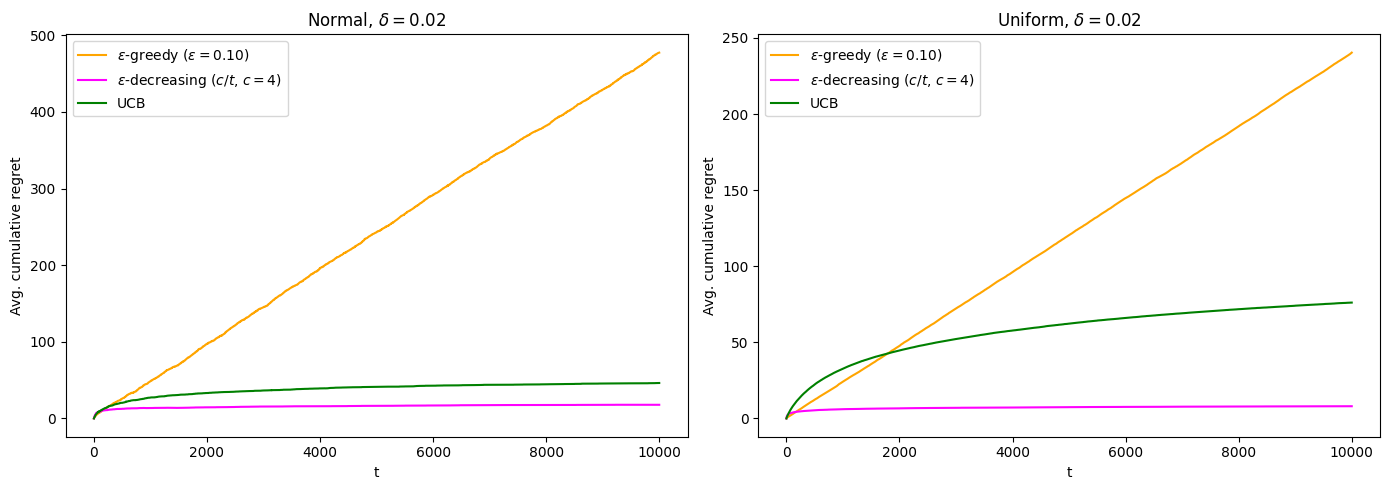

In [18]:
# --- Part 2: Time-dependent epsilon-greedy ---
# Compare fixed eps=0.10 vs decreasing eps vs UCB
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pol_fixed = lambda counts, sums, t: eps_greedy_fast(counts, sums, t, eps=0.10)
pol_dec = lambda counts, sums, t: eps_greedy_decreasing_fast(counts, sums, t, c=4.0)

for pol, name, col in [
    (pol_fixed, r"$\epsilon$-greedy ($\epsilon=0.10$)", "orange"),
    (pol_dec, r"$\epsilon$-decreasing ($c/t$, $c=4$)", "magenta"),
    (ucb_fast, "UCB", "green"),
]:
    R_normal = eval_pol_fast(pol, n, delta, n_rep, normal=True)
    R_uniform = eval_pol_fast(pol, n, delta, n_rep, normal=False)
    axes[0].plot(np.mean(R_normal, axis=0), label=name, color=col)
    axes[1].plot(np.mean(R_uniform, axis=0), label=name, color=col)

axes[0].set_title(f"Normal, $\\delta = {delta}$")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Avg. cumulative regret")
axes[0].legend()

axes[1].set_title(f"Uniform, $\\delta = {delta}$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Avg. cumulative regret")
axes[1].legend()

plt.tight_layout()
plt.show()

### Discussion

**1. How exploration affects performance:**

A higher $\epsilon$ means the agent explores more — it pulls a random arm with probability $\epsilon$ at every round. This increases the chance of pulling the suboptimal arm, which directly adds to cumulative regret. Conversely, a very small $\epsilon$ means the agent exploits almost always: it quickly locks onto whichever arm looked best in the first few pulls. This can be problematic if the initial estimate is wrong (especially with noisy rewards), leading to consistently pulling the wrong arm.

**2. Can too much exploration hurt long-run performance?**

Yes. Since the regret of $\epsilon$-greedy grows linearly with slope proportional to $\epsilon \cdot \Delta$, a large $\epsilon$ (e.g., $0.20$) leads to a steep, persistent regret increase. The agent keeps wasting pulls on the inferior arm even after it has gathered enough data to identify the best arm with high confidence. The plots show that $\epsilon = 0.20$ has roughly double the final regret of $\epsilon = 0.10$.

**3. Time-dependent $\epsilon$: $\epsilon(t) = c / t$**

When the decreasing-exploration policy uses $\epsilon_t=c/t$, the constant $c$ strongly affects performance. If $c$ is too small, exploration may decay too quickly, especially in noisy environments such as the normal case, and the algorithm may commit too early to the wrong arm. Increasing $c$ provides more exploration in the early rounds, which can improve identification of the optimal arm. Once the correct arm has been learned, the remaining exploration is only of order $\sum_{t=1}^n c/t \approx c\log n$, so cumulative regret can grow very slowly and appear almost flat compared with linear-regret policies.

The key advantage is that the cumulative regret becomes **sublinear**: since $\sum_{t=1}^{n} c/t = O(\log n)$, the expected number of exploratory pulls grows only logarithmically, yielding $O(\log n)$ regret instead of $O(n)$. The plots confirm that the $\epsilon$-decreasing curve flattens over time, unlike the fixed-$\epsilon$ curves which grow linearly.

### Alternative way for time dependent eps

In [6]:
def tuned_eps_greedy_cb_fast(counts, sums, t, d):
    """
    Fast Cesa-Bianchi / Auer tuned epsilon-greedy:
        epsilon_t = min(1, 12 / (d^2 * t))
    """
    K = len(counts)

    # play each arm once at the beginning
    if t <= K:
        return t - 1

    eps_t = min(1.0, 12.0 / (d**2 * t))

    means = sums / np.where(counts > 0, counts, 1)
    greedy_arm = np.argmax(means)

    # exploit with probability 1 - eps_t
    if np.random.rand() < 1 - eps_t:
        return greedy_arm

    # explore: choose a random arm
    return np.random.randint(K)

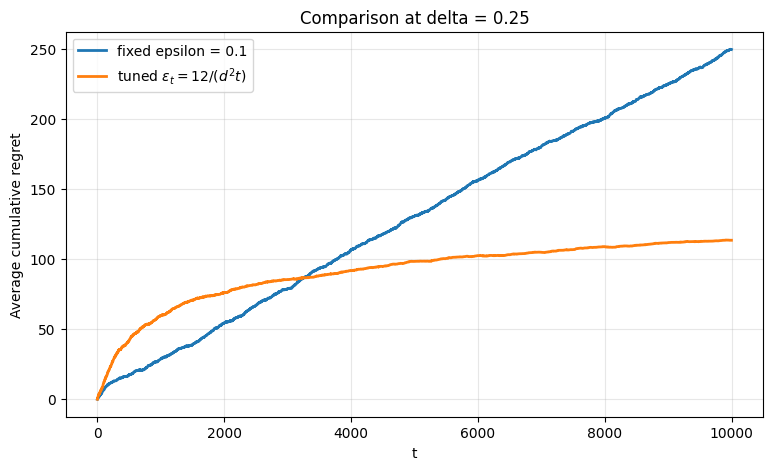

In [7]:
delta = 0.25
n = 10000
n_rep = 50
d = 0.5 - delta

R_fixed = eval_pol_fast(
    lambda counts, sums, t: eps_greedy_fast(counts, sums, t, eps=0.1),
    n=n,
    delta=delta,
    n_rep=n_rep,
    normal=True
)

R_cb = eval_pol_fast(
    lambda counts, sums, t: tuned_eps_greedy_cb_fast(counts, sums, t, d=d),
    n=n,
    delta=delta,
    n_rep=n_rep,
    normal=True
)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 5))
plt.plot(np.mean(R_fixed, axis=0), label="fixed epsilon = 0.1", linewidth=2)
plt.plot(np.mean(R_cb, axis=0), label=r"tuned $\epsilon_t = 12/(d^2 t)$", linewidth=2)
plt.xlabel("t")
plt.ylabel("Average cumulative regret")
plt.title(f"Comparison at delta = {delta}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Cesa-Bianchi’s tuned epsilon-greedy algorithm is a time-dependent version of epsilon-greedy for stochastic bandits. At each round, the learner exploits the arm with the highest empirical mean with probability $1-\epsilon_t$ and explores a random arm with probability $\epsilon_t$, where the tuned schedule is $\epsilon_t = \frac{12}{d^2 t}$. The idea is to explore more at the beginning and less over time. The parameter $d$ is assumed to be a known lower bound on the true reward gap, so this rule is mainly theoretical: it shows how a well-tuned exploration schedule should behave, but it relies on information that a real learner usually does not know in advance. In simulations, however, this assumption can still be used because the data-generating process is known by construction. In this setting, the corresponding performance guarantee is $O\left(\frac{K}{dn}\right)$.

# Task 3: Thompson Sampling (K = 2)

Thompson Sampling is a Bayesian bandit algorithm that maintains a posterior distribution for the unknown reward probability of each arm. In the Bernoulli case, each arm starts with a Beta(1,1) prior. At each round, the algorithm samples one value from the current posterior of every arm and selects the arm with the highest sampled value. After observing the reward, it updates the posterior of the chosen arm using the Beta-Bernoulli update rule. This mechanism creates a natural balance between exploration and exploitation: arms with strong past performance are likely to be selected often, while uncertain arms can still be explored because their posterior samples may occasionally be high.

Since the Beta-Bernoulli conjugate update requires binary rewards ($r \in \{0,1\}$), we introduce a Bernoulli reward setting where arm $i$ yields reward $r \sim \text{Bernoulli}(\mu_i)$ with $\mu_1 = 1/2$ and $\mu_2 = \delta$. We also create a generalized evaluation function that supports $K \geq 2$ arms.

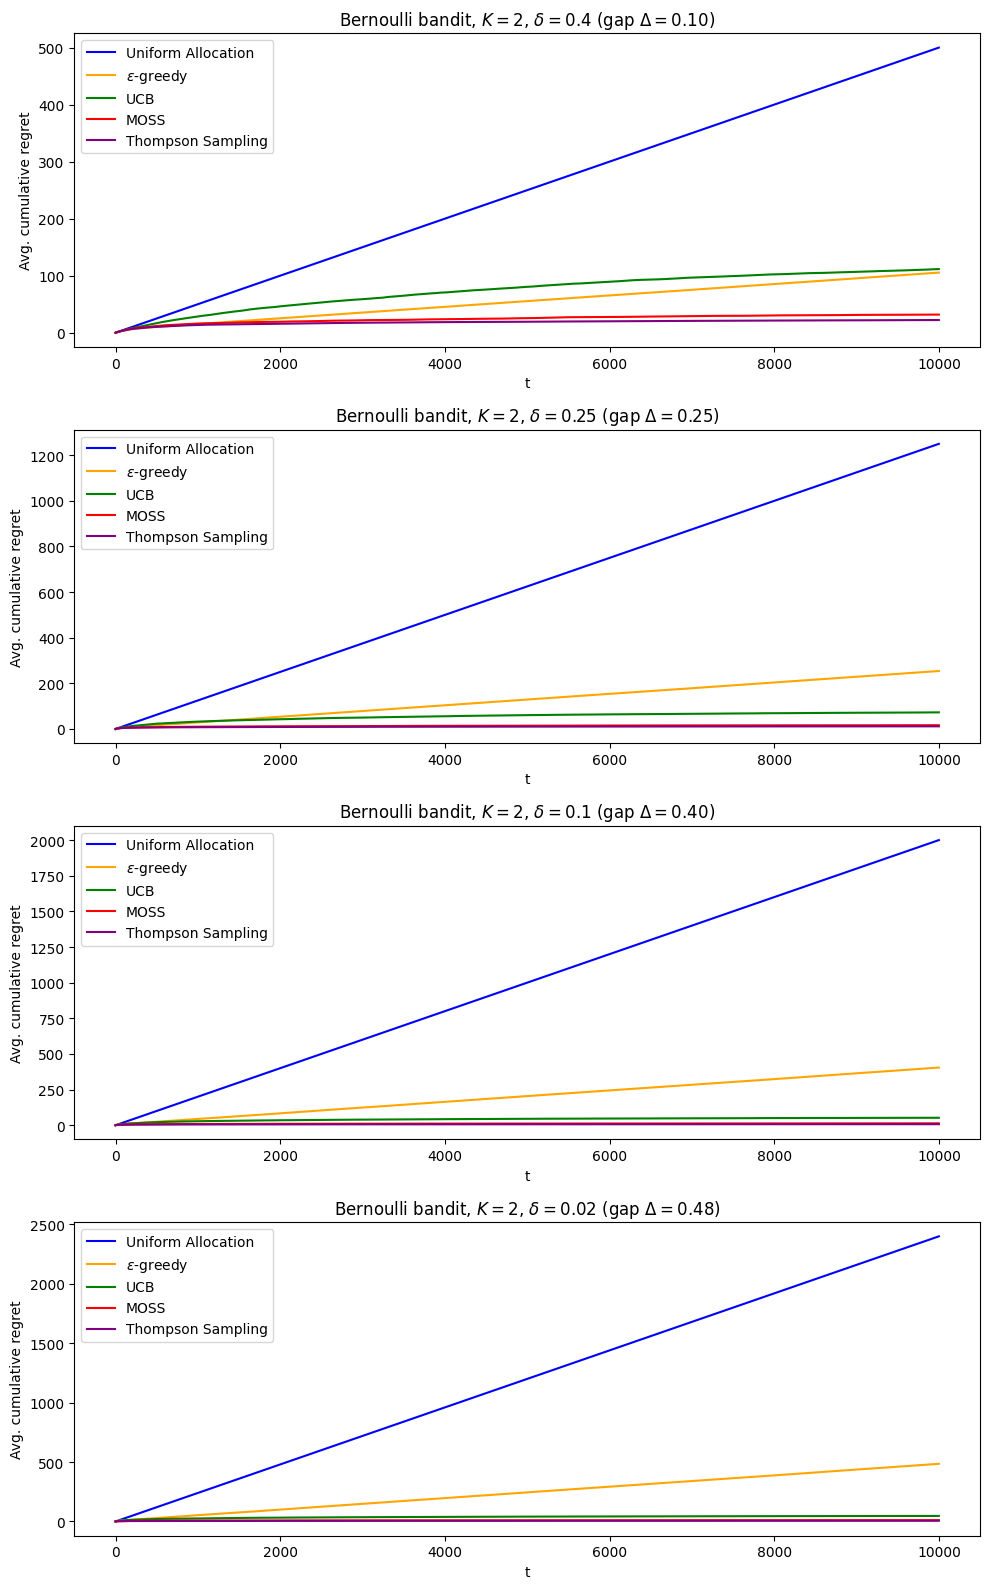

In [8]:
# --- K = 2 arms: compare Thompson Sampling to other policies across deltas ---
n = 10000
n_rep = 50
deltas = [0.40, 0.25, 0.10, 0.02]

policies_K2 = {
    "Uniform Allocation": unif_alloc_fast,
    r"$\epsilon$-greedy": eps_greedy_fast,
    "UCB": ucb_fast,
    "MOSS": moss_fast,
    "Thompson Sampling": lambda counts, sums, t: thompson_sampling_fast(counts, sums, t, K=2),
}
colors_K2 = {
    "Uniform Allocation": "blue",
    r"$\epsilon$-greedy": "orange",
    "UCB": "green",
    "MOSS": "red",
    "Thompson Sampling": "purple",
}

fig, axes = plt.subplots(len(deltas), 1, figsize=(10, 4 * len(deltas)))

for row, delta in enumerate(deltas):
    mus = [0.5, delta]
    for name, pol in policies_K2.items():
        R = eval_pol_bernoulli_fast(pol, n, 2, mus, n_rep)
        axes[row].plot(np.mean(R, axis=0), label=name, color=colors_K2[name])

    axes[row].set_title(f"Bernoulli bandit, $K=2$, $\\delta = {delta}$ (gap $\\Delta = {0.5 - delta:.2f}$)")
    axes[row].set_xlabel("t")
    axes[row].set_ylabel("Avg. cumulative regret")
    axes[row].legend()

plt.tight_layout()
plt.show()

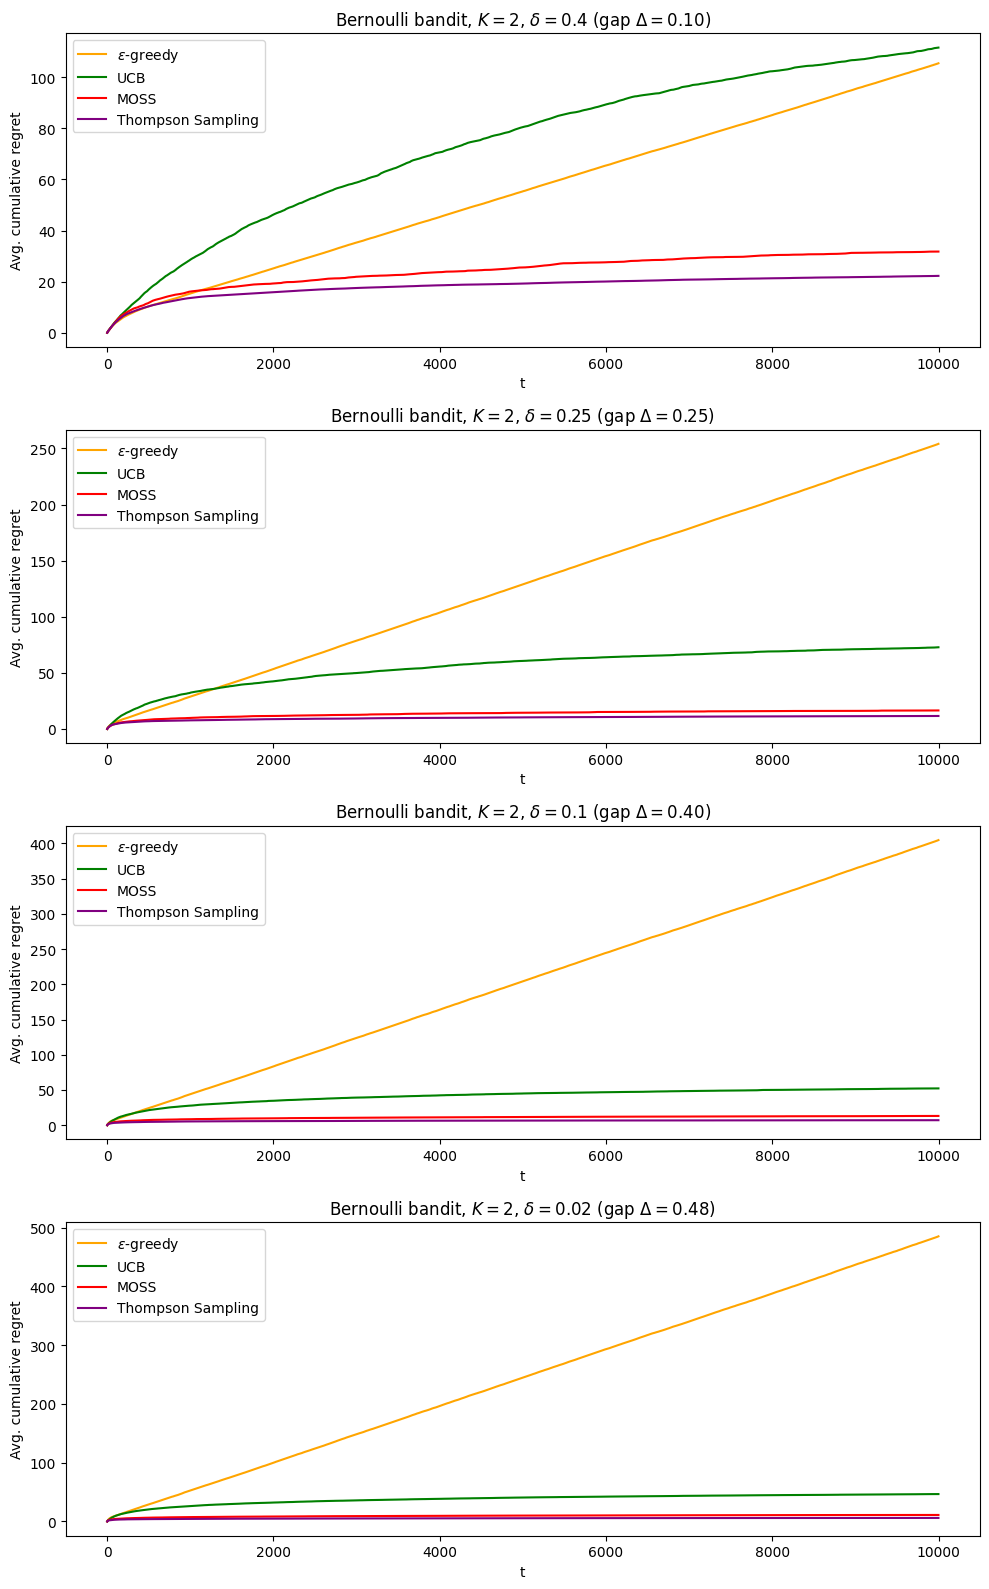

In [20]:
# --- K = 2 arms: compare Thompson Sampling to other policies across deltas (without Uniform Allocation) ---
n = 10000
n_rep = 50
deltas = [0.40, 0.25, 0.10, 0.02]

policies_K2 = {
    r"$\epsilon$-greedy": eps_greedy_fast,
    "UCB": ucb_fast,
    "MOSS": moss_fast,
    "Thompson Sampling": lambda counts, sums, t: thompson_sampling_fast(counts, sums, t, K=2),
}

colors_K2 = {
    r"$\epsilon$-greedy": "orange",
    "UCB": "green",
    "MOSS": "red",
    "Thompson Sampling": "purple",
}

fig, axes = plt.subplots(len(deltas), 1, figsize=(10, 4 * len(deltas)))

for row, delta in enumerate(deltas):
    mus = [0.5, delta]
    for name, pol in policies_K2.items():
        R = eval_pol_bernoulli_fast(pol, n, 2, mus, n_rep)
        axes[row].plot(np.mean(R, axis=0), label=name, color=colors_K2[name])

    axes[row].set_title(f"Bernoulli bandit, $K=2$, $\\delta = {delta}$ (gap $\\Delta = {0.5 - delta:.2f}$)")
    axes[row].set_xlabel("t")
    axes[row].set_ylabel("Avg. cumulative regret")
    axes[row].legend()

plt.tight_layout()
plt.show()

### Discussion (K = 2)

Thompson Sampling achieves **sublinear regret** comparable to UCB and MOSS, and often outperforms them — especially for smaller gaps ($\delta$ close to $1/2$). This is because Thompson Sampling naturally balances exploration and exploitation through posterior sampling: arms with uncertain posteriors are more likely to produce high samples (encouraging exploration), while arms with well-estimated high means dominate as confidence grows (encouraging exploitation).

Unlike UCB which uses deterministic upper confidence bounds, Thompson Sampling's randomised exploration adapts more smoothly to the problem difficulty. It does not require tuning any hyperparameters (unlike $\epsilon$-greedy), making it a very practical algorithm.

## Task 3 : Thompson Sampling with K = 3 arms

We now extend the analysis to $K = 3$ arms with Bernoulli rewards. The arm means are $\mu_1 = 1/2$ (optimal), $\mu_2 = \delta$, and $\mu_3 = \delta/2$ (worst arm). We adapt UCB, MOSS, $\epsilon$-greedy, and Uniform Allocation to handle 3 arms.

In [9]:
# --- K = 3 arm policies (adapted from 2-arm fast versions) ---

def unif_alloc_K3(counts, sums, t):
    return (t - 1) % 3

def eps_greedy_K3(counts, sums, t, eps=0.1):
    K = 3
    if t <= K:
        return t - 1
    randv = np.random.binomial(1, 1 - eps)
    means = sums / np.where(counts > 0, counts, 1)
    if randv == 1:
        return np.argmax(means)
    else:
        # explore: pick uniformly among the non-best arms
        best = np.argmax(means)
        others = [a for a in range(K) if a != best]
        return others[np.random.randint(len(others))]

def ucb_K3(counts, sums, t):
    K = 3
    if t <= K:
        return t - 1
    means = sums / np.where(counts > 0, counts, 1)
    bonuses = np.sqrt(2 * np.log(1 + t * np.log(t)**2) / np.where(counts > 0, counts, 1))
    return np.argmax(means + bonuses)

def moss_K3(counts, sums, t):
    K = 3
    if t <= K:
        return t - 1
    means = sums / np.where(counts > 0, counts, 1)
    bonuses = np.sqrt(np.maximum(0, np.log(t / (K * np.where(counts > 0, counts, 1)))) / np.where(counts > 0, counts, 1))
    return np.argmax(means + bonuses)

def thompson_K3(counts, sums, t):
    return thompson_sampling_fast(counts, sums, t, K=3)

print("K=3 policies defined.")

K=3 policies defined.


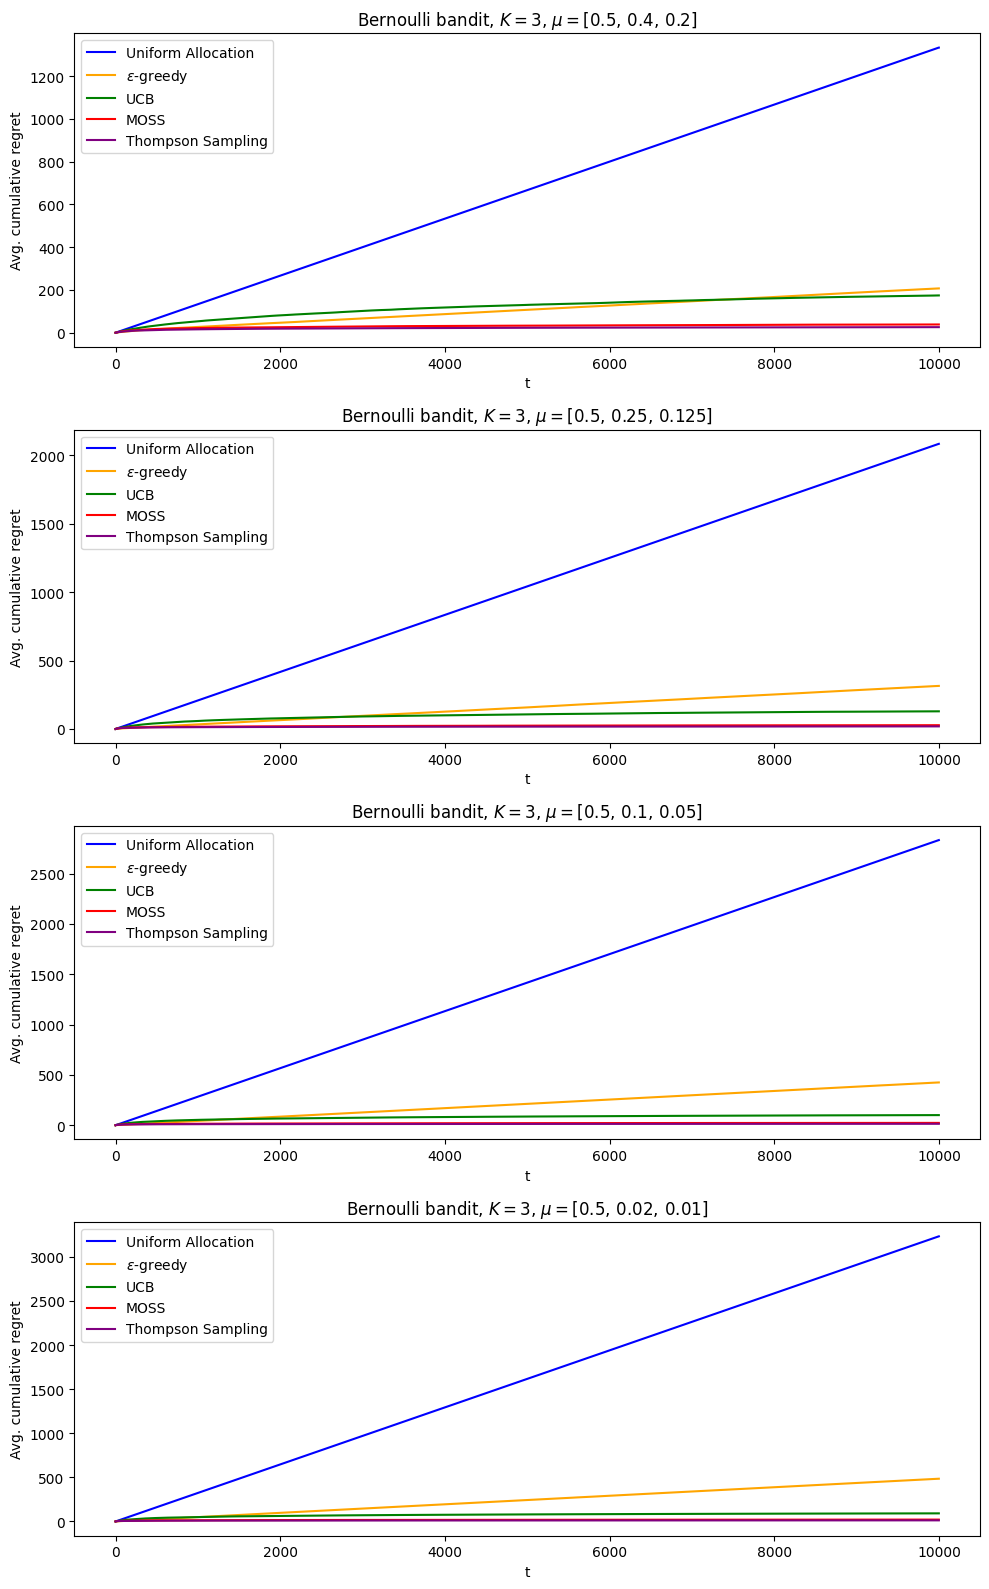

In [10]:
# --- K = 3 arms: compare all policies across deltas ---
n = 10000
n_rep = 50
deltas = [0.40, 0.25, 0.10, 0.02]

policies_K3 = {
    "Uniform Allocation": unif_alloc_K3,
    r"$\epsilon$-greedy": eps_greedy_K3,
    "UCB": ucb_K3,
    "MOSS": moss_K3,
    "Thompson Sampling": thompson_K3,
}
colors_K3 = {
    "Uniform Allocation": "blue",
    r"$\epsilon$-greedy": "orange",
    "UCB": "green",
    "MOSS": "red",
    "Thompson Sampling": "purple",
}

fig, axes = plt.subplots(len(deltas), 1, figsize=(10, 4 * len(deltas)))

for row, delta in enumerate(deltas):
    mus = [0.5, delta, delta / 2]  # 3 arms: optimal, suboptimal, worst
    for name, pol in policies_K3.items():
        R = eval_pol_bernoulli_fast(pol, n, 3, mus, n_rep)
        axes[row].plot(np.mean(R, axis=0), label=name, color=colors_K3[name])

    axes[row].set_title(
        f"Bernoulli bandit, $K=3$, $\\mu = [0.5,\\, {delta},\\, {delta/2}]$"
    )
    axes[row].set_xlabel("t")
    axes[row].set_ylabel("Avg. cumulative regret")
    axes[row].legend()

plt.tight_layout()
plt.show()

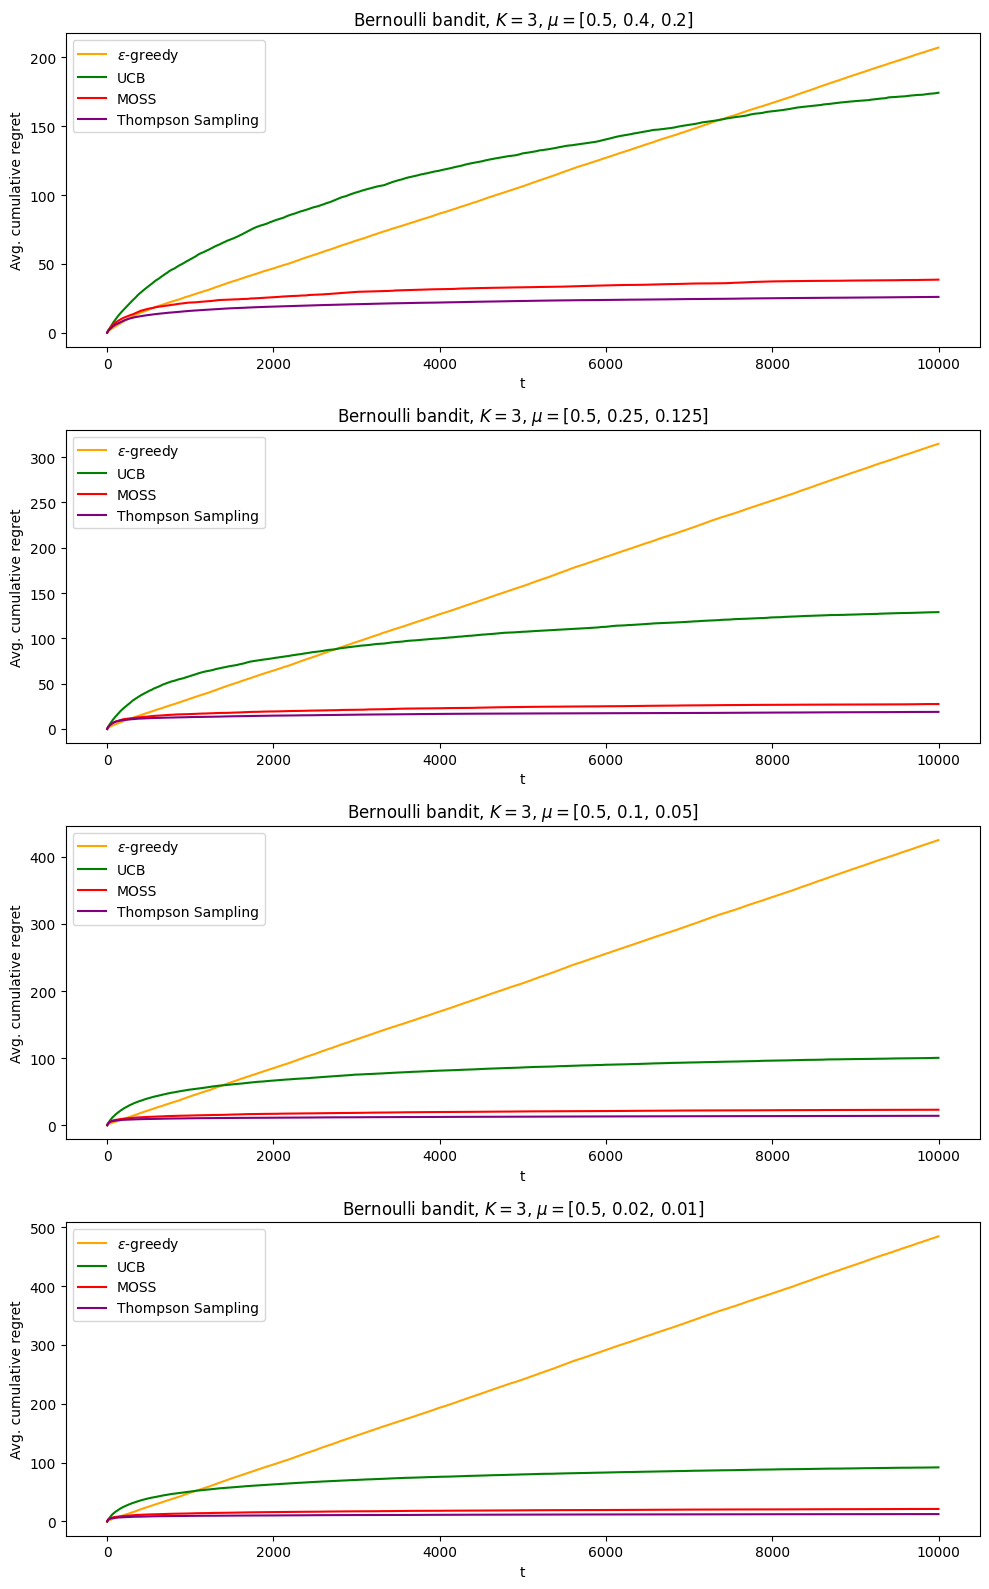

In [21]:
# --- K = 3 arms: compare policies across deltas (without Uniform Allocation) ---
n = 10000
n_rep = 50
deltas = [0.40, 0.25, 0.10, 0.02]

policies_K3 = {
    r"$\epsilon$-greedy": eps_greedy_K3,
    "UCB": ucb_K3,
    "MOSS": moss_K3,
    "Thompson Sampling": thompson_K3,
}

colors_K3 = {
    r"$\epsilon$-greedy": "orange",
    "UCB": "green",
    "MOSS": "red",
    "Thompson Sampling": "purple",
}

fig, axes = plt.subplots(len(deltas), 1, figsize=(10, 4 * len(deltas)))

for row, delta in enumerate(deltas):
    mus = [0.5, delta, delta / 2]  # 3 arms: optimal, suboptimal, worst
    for name, pol in policies_K3.items():
        R = eval_pol_bernoulli_fast(pol, n, 3, mus, n_rep)
        axes[row].plot(np.mean(R, axis=0), label=name, color=colors_K3[name])

    axes[row].set_title(
        f"Bernoulli bandit, $K=3$, $\\mu = [0.5,\\, {delta},\\, {delta/2}]$"
    )
    axes[row].set_xlabel("t")
    axes[row].set_ylabel("Avg. cumulative regret")
    axes[row].legend()

plt.tight_layout()
plt.show()

### Discussion (K = 3)

With $K = 3$ arms ($\mu = [0.5, \delta, \delta/2]$), the problem becomes harder than the $K = 2$ case for two reasons:

1. **More suboptimal arms to eliminate.** The agent must now identify the best arm among three candidates rather than two, requiring more exploration before it can confidently exploit.

2. **Regret accumulates from two sources.** Each pull of arm 2 incurs regret $\Delta_2 = 0.5 - \delta$ and each pull of arm 3 incurs regret $\Delta_3 = 0.5 - \delta/2$, so the total regret grows faster.

**Key observations:**

- **Thompson Sampling** continues to perform excellently, often matching or outperforming UCB and MOSS. Its Bayesian exploration naturally scales to more arms without any hyperparameter changes.
- **UCB and MOSS** still achieve sublinear regret, but the absolute regret is higher than in the $K = 2$ case because there are more arms to explore.
- **Uniform Allocation** suffers even more: it now pulls the optimal arm only $1/3$ of the time instead of $1/2$.
- **$\epsilon$-greedy** also sees higher regret because its random exploration is now split across two suboptimal arms.

Overall, the ranking of algorithms is consistent with the $K = 2$ case: Thompson Sampling, UCB, and MOSS dominate, while Uniform Allocation and fixed $\epsilon$-greedy lag behind with linear regret.

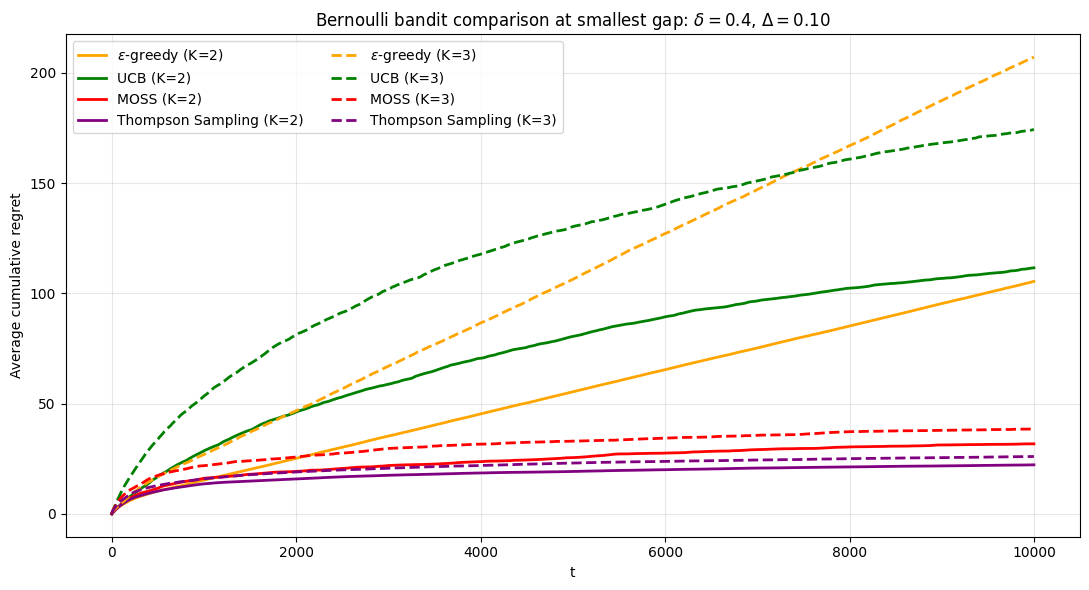

In [22]:
# --- Single plot: K=2 vs K=3 at the smallest gap (delta = 0.40), without Uniform Allocation ---

import numpy as np
import matplotlib.pyplot as plt

n = 10000
n_rep = 50
delta = 0.40   # smallest gap: Delta = 0.5 - 0.40 = 0.10

# Means
mus_K2 = [0.5, delta]
mus_K3 = [0.5, delta, delta / 2]

# Policies
policies_K2 = {
    r"$\epsilon$-greedy": eps_greedy_fast,
    "UCB": ucb_fast,
    "MOSS": moss_fast,
    "Thompson Sampling": lambda counts, sums, t: thompson_sampling_fast(counts, sums, t, K=2),
}

policies_K3 = {
    r"$\epsilon$-greedy": eps_greedy_K3,
    "UCB": ucb_K3,
    "MOSS": moss_K3,
    "Thompson Sampling": thompson_K3,
}

# Same color = same algorithm, linestyle = K
colors = {
    r"$\epsilon$-greedy": "orange",
    "UCB": "green",
    "MOSS": "red",
    "Thompson Sampling": "purple",
}

plt.figure(figsize=(11, 6))

# K = 2
for name, pol in policies_K2.items():
    R = eval_pol_bernoulli_fast(pol, n, 2, mus_K2, n_rep)
    plt.plot(
        np.mean(R, axis=0),
        label=f"{name} (K=2)",
        color=colors[name],
        linestyle="-",
        linewidth=2
    )

# K = 3
for name, pol in policies_K3.items():
    R = eval_pol_bernoulli_fast(pol, n, 3, mus_K3, n_rep)
    plt.plot(
        np.mean(R, axis=0),
        label=f"{name} (K=3)",
        color=colors[name],
        linestyle="--",
        linewidth=2
    )

plt.title(rf"Bernoulli bandit comparison at smallest gap: $\delta={delta}$, $\Delta={0.5-delta:.2f}$")
plt.xlabel("t")
plt.ylabel("Average cumulative regret")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Task 4: Regret growth

For each algorithm we plot $R(\pi, n) / n$, the average cumulative regret divided by the number of rounds. If this ratio converges to a **positive constant**, the regret is **linear**. If it converges to **zero**, the regret is **sublinear**.

We use the Bernoulli bandit setting with $K=2$, $n = 10\,000$, $n_{\mathrm{rep}} = 50$.

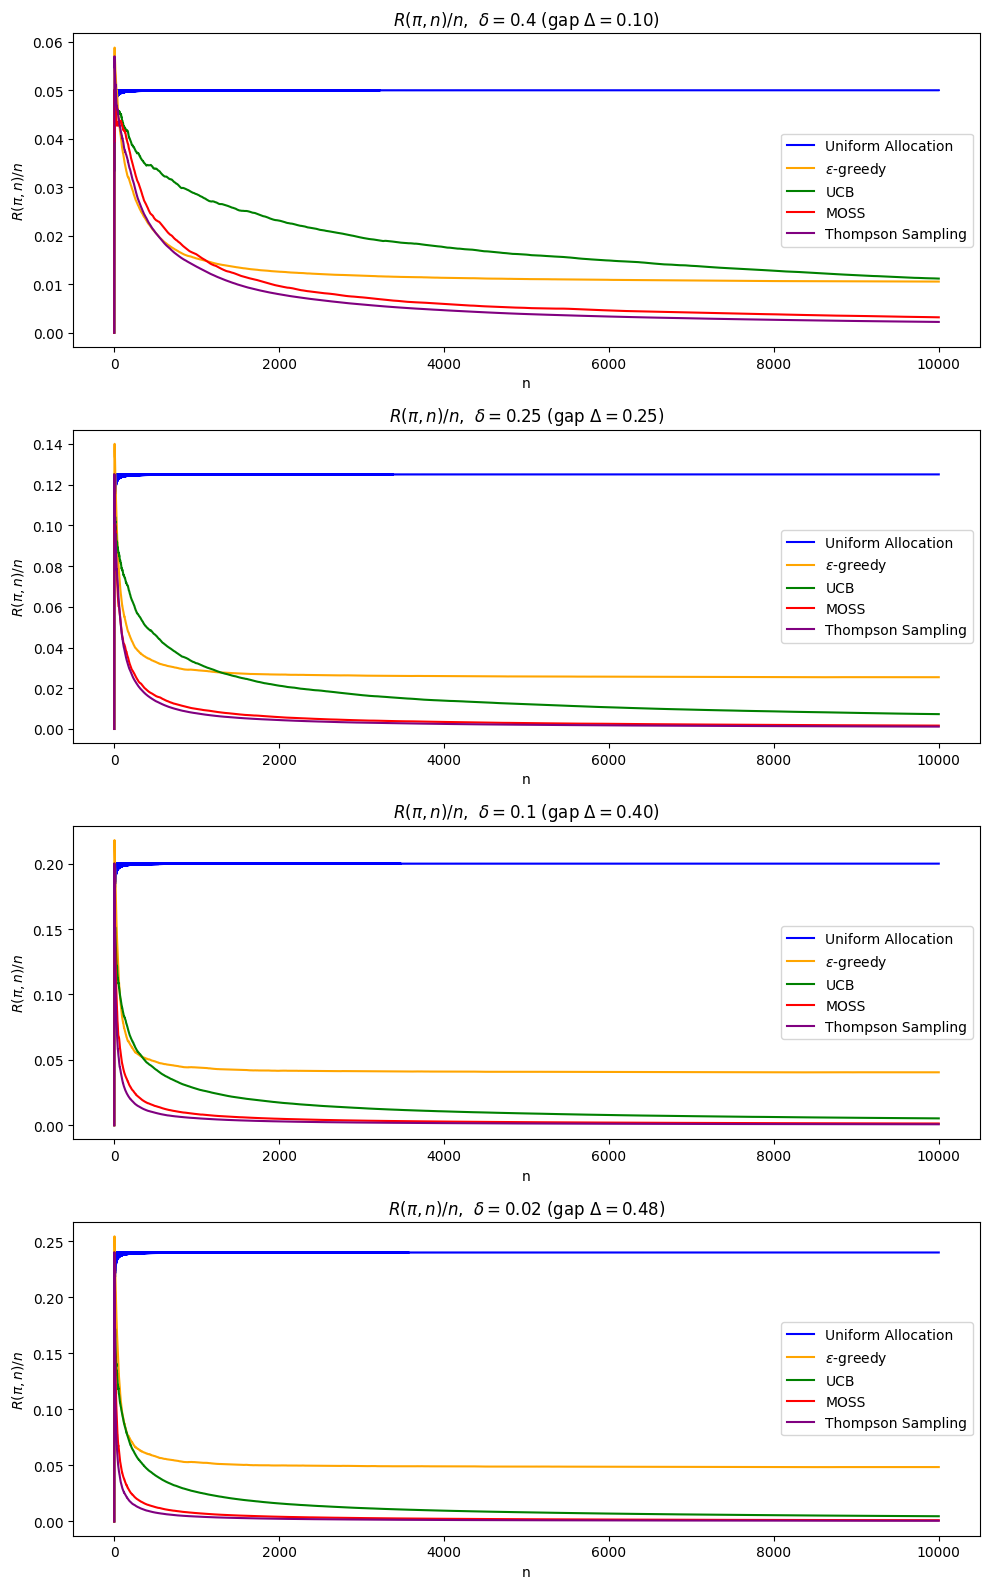

In [11]:
n = 10000
n_rep = 50
deltas = [0.40, 0.25, 0.10, 0.02]
t_range = np.arange(1, n + 1)

policies_all = {
    "Uniform Allocation": unif_alloc_fast,
    r"$\epsilon$-greedy": eps_greedy_fast,
    "UCB": ucb_fast,
    "MOSS": moss_fast,
    "Thompson Sampling": lambda counts, sums, t: thompson_sampling_fast(counts, sums, t, K=2),
}
colors_all = {
    "Uniform Allocation": "blue",
    r"$\epsilon$-greedy": "orange",
    "UCB": "green",
    "MOSS": "red",
    "Thompson Sampling": "purple",
}

fig, axes = plt.subplots(len(deltas), 1, figsize=(10, 4 * len(deltas)))

for row, delta in enumerate(deltas):
    mus = [0.5, delta]
    for name, pol in policies_all.items():
        R = eval_pol_bernoulli_fast(pol, n, 2, mus, n_rep)
        avg_regret = np.mean(R, axis=0)
        axes[row].plot(avg_regret / t_range, label=name, color=colors_all[name])

    axes[row].set_title(f"$R(\\pi, n) / n$,  $\\delta = {delta}$ (gap $\\Delta = {0.5 - delta:.2f}$)")
    axes[row].set_xlabel("n")
    axes[row].set_ylabel("$R(\\pi, n) / n$")
    axes[row].legend()

plt.tight_layout()
plt.show()

### Discussion

By plotting $R(\pi, n)/n$ we can visually distinguish **linear** from **sublinear** regret:

**Linear regret** ($R(\pi,n)/n \to c > 0$):
- **Uniform Allocation**: $R(\pi,n)/n$ converges to $\Delta/2$ because the suboptimal arm is pulled 50% of the time. This is the worst-performing policy.
- **$\epsilon$-greedy** (fixed $\epsilon = 0.1$): $R(\pi,n)/n$ converges to a positive constant $\approx \epsilon \cdot \Delta / 2$. The fixed exploration rate means a constant fraction of pulls are wasted on the inferior arm forever.

**Sublinear regret** ($R(\pi,n)/n \to 0$):
- **UCB**: The ratio clearly decays toward zero. This is consistent with the theoretical result that UCB achieves $O(\log n)$ regret, so $R(\pi,n)/n = O(\log n / n) \to 0$.
- **MOSS**: Also converges to zero. MOSS is minimax optimal with $O(\sqrt{Kn})$ worst-case regret, giving $R(\pi,n)/n = O(1/\sqrt{n}) \to 0$.
- **Thompson Sampling**: Converges to zero as well. Thompson Sampling is known to achieve the Lai-Robbins lower bound, i.e., $O(\log n)$ regret, matching UCB.

These observations are fully consistent with the theoretical results from the lecture:
- The **Lai-Robbins lower bound** states that any consistent policy must have $R(\pi, n) \geq \frac{\log n}{\mathrm{KL}(\mu_2, \mu_1)} + o(\log n)$, i.e., at least logarithmic regret.
- UCB and Thompson Sampling achieve this $O(\log n)$ bound (instance-dependent).
- Policies with constant exploration rates (uniform, fixed $\epsilon$-greedy) cannot achieve sublinear regret because they never stop exploring.